In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv(r"C:\Users\solom\OneDrive\Desktop\econ206_final_project\japan_data_cleaned.csv")
# removing rows < 1976 (No savings rate data)
df = df[df['year'] >= 1976]
df.head(10)
# column meanings: 
# iso - ISO 3166-1 alpha-3 country code
# year - the year of the observation
# Real output (rgdpo)
# Population (pop)
# Capital stock (rnna)
# Labor share (labsh)
# Depreciation rate (delta)
# Savings Rate (savings_rate)

,iso3,Country,year,delta,labsh,pop,rgdpo,rnna,savings_rate
0,JPN,Japan,1976,0.033833,0.617359,114.502795,2140760.25,8684773,35.392825
1,JPN,Japan,1977,0.033521,0.620946,115.574277,2288072.75,9251136,35.259136
2,JPN,Japan,1978,0.033337,0.611577,116.576944,2460841.75,9869457,35.474432
3,JPN,Japan,1979,0.033328,0.607692,117.521556,2625492.00,10512650,34.508197
4,JPN,Japan,1980,0.033443,0.609879,118.358756,2778892.00,11087465,34.235397
5,JPN,Japan,1981,0.033580,0.611526,118.994053,2771451.00,11661513,34.611069
6,JPN,Japan,1982,0.033680,0.613019,119.485775,2730068.75,12206848,33.390769
7,JPN,Japan,1983,0.033752,0.615773,119.948947,2694770.75,12716322,32.961817
8,JPN,Japan,1984,0.033893,0.606810,120.384394,2713529.00,13244571,33.718822
9,JPN,Japan,1985,0.034141,0.595854,120.832163,2794807.25,13826276,34.353794


In [3]:
# calculating average population growth rate (n), depreciation rate (δ), saving rate (σ), and labor share (1 − α) 
df['pop_growth'] = df['pop'].pct_change()
n = df['pop_growth'].mean()
delta = df['delta'].mean()
sigma = df['savings_rate'].mean() / 100
alpha = 1 - df['labsh'].mean()  

print(f"Average population growth rate (n): {n}")
print(f"Average depreciation rate (δ): {delta}")
print(f"Average saving rate (σ): {sigma}")
print(f"Average labor share (1 − α): {df['labsh'].mean()}")

Average population growth rate (n): 0.0017659720785368471
Average depreciation rate (δ): 0.037779132
Average saving rate (σ): 0.2976991941041666
Average labor share (1 − α): 0.5779211533958334


In [4]:
# replacing relevant columns w/ average values
df['avg_savings_rate'] = df['savings_rate'].mean() 
df['avg_labsh'] = df['labsh'].mean()
df['avg_delta'] = df['delta'].mean()
df['avg_pop_growth'] = df['pop_growth'].mean()

# dropping original columns now that we have the averages
df = df.drop(columns=['savings_rate', 'labsh', 'delta', 'pop_growth'])

In [5]:
# Constructing the per-capita capital, kData, using the data on capital stock and population over time.
df['per_capita_capital'] = df['rnna'] / df['pop']
df.tail()

,iso3,Country,year,pop,rgdpo,rnna,avg_savings_rate,avg_labsh,avg_delta,avg_pop_growth,per_capita_capital
43,JPN,Japan,2019,126.699424,5538041.0,29401234,29.769919,0.577921,0.037779,0.001766,232054.993399
44,JPN,Japan,2020,126.304543,5301858.5,29553106,29.769919,0.577921,0.037779,0.001766,233982.921739
45,JPN,Japan,2021,125.679338,5380121.5,29706136,29.769919,0.577921,0.037779,0.001766,236364.516815
46,JPN,Japan,2022,124.997578,5390744.5,29845872,29.769919,0.577921,0.037779,0.001766,238771.602439
47,JPN,Japan,2023,124.370947,5505348.0,29998940,29.769919,0.577921,0.037779,0.001766,241205.367681


In [6]:
# save the dataframe to a CSV file

df.to_csv('japan_per_capita_capital.csv', index=False)

## Question 5: Model Predictions at t = 0

In [7]:
# ── Q5: Model Predictions at t = 0 ───────────────────────────────────────────
# Per-capita production function: f(k) = A * k^α
kData0 = df['per_capita_capital'].iloc[0]   # k₀ from data

# Step 1: try A₀ = 1
A = 1
yModel0       = A * kData0 ** alpha
delta_kModel0 = sigma * yModel0 - (delta + n) * kData0

print(f"With A = 1:")
print(f"  ΔkModel₀ = {delta_kModel0:,.4f}")

# Step 2: if Δk₀ < 0, find minimum integer A that gives Δk₀ > 0
if delta_kModel0 < 0:
    print(f"  → Δk₀ is negative. Searching for minimum integer A...")
    A = 1
    while True:
        A += 1
        yModel0       = A * kData0 ** alpha
        delta_kModel0 = sigma * yModel0 - (delta + n) * kData0
        if delta_kModel0 > 0:
            break
    print(f"  → Minimum integer A that ensures positive capital accumulation: A = {A}")

# Step 3: compute all model-predicted values with chosen A
yModel0       = A * kData0 ** alpha
sModel0       = sigma * yModel0
cModel0       = (1 - sigma) * yModel0
delta_kModel0 = sigma * yModel0 - (delta + n) * kData0

print(f"\n── Q5 Results (A = {A}) ─────────────────────────────────────")
print(f"  kData₀    = {kData0:>15,.4f}  (per-capita capital, t=0)")
print(f"  yModel₀   = {yModel0:>15,.4f}  (per-capita output)")
print(f"  sModel₀   = {sModel0:>15,.4f}  (per-capita saving)")
print(f"  cModel₀   = {cModel0:>15,.4f}  (per-capita consumption)")
print(f"  ΔkModel₀  = {delta_kModel0:>15,.4f}  (change in per-capita capital)")

With A = 1:
  ΔkModel₀ = -2,965.2465
  → Δk₀ is negative. Searching for minimum integer A...
  → Minimum integer A that ensures positive capital accumulation: A = 88

── Q5 Results (A = 88) ─────────────────────────────────────
  kData₀    =     75,847.6944  (per-capita capital, t=0)
  yModel₀   =     10,097.2504  (per-capita output)
  sModel₀   =      3,005.9433  (per-capita saving)
  cModel₀   =      7,091.3071  (per-capita consumption)
  ΔkModel₀  =          6.5383  (change in per-capita capital)


## Question 6: Theoretical Steady-State Capital Stock

In [8]:
# ── Steady-state condition:  σ·f(k*) = (n+δ)·k* ─────────────────────────────
# Substituting f(k) = A·k^α:
#   σ·A·k*^α = (n+δ)·k*
#   k*^(1-α)  = σ·A / (n+δ)
#   k*        = ( σ·A / (n+δ) )^( 1/(1-α) )
k_star = (sigma * A / (delta + n)) ** (1 / (1 - alpha))
y_star = A * k_star ** alpha
c_star = (1 - sigma) * y_star

print(f"Parameters used:")
print(f"  A     = {A:.6f}")
print(f"  α     = {alpha:.4f}")
print(f"  σ     = {sigma:.4f}")
print(f"  δ     = {delta:.4f}")
print(f"  n     = {n:.4f}")
print(f"\n── Q6 Steady-State Values ────────────────────────────────────")
print(f"  k* (per-capita capital) = {k_star:>15,.4f}")
print(f"  y* (per-capita output)  = {y_star:>15,.4f}")
print(f"  c* (per-capita consump) = {c_star:>15,.4f}")
print(f"\n  Verification — σ·f(k*):  {sigma*y_star:,.4f}")
print(f"               (n+δ)·k*:  {(delta+n)*k_star:,.4f}  ✓")

Parameters used:
  A     = 88.000000
  α     = 0.4221
  σ     = 0.2977
  δ     = 0.0378
  n     = 0.0018

── Q6 Steady-State Values ────────────────────────────────────
  k* (per-capita capital) =     76,134.0139
  y* (per-capita output)  =     10,113.3210
  c* (per-capita consump) =      7,102.5935

  Verification — σ·f(k*):  3,010.7275
               (n+δ)·k*:  3,010.7275  ✓


## Question 7: Golden Rule Capital Stock & Solow Diagram

In [9]:
# ── Golden Rule Capital Stock ────────────────────────────────────────────────
# Golden rule maximises c = f(k) - (n+δ)k
# FOC:  f'(k_gr) = n+δ
#   → α·A·k_gr^(α-1) = n+δ
#   → k_gr = ( α·A / (n+δ) )^(1/(1−α))
k_gr = (alpha * A / (delta + n)) ** (1 / (1 - alpha))
y_gr = A * k_gr ** alpha
c_gr = y_gr - (delta + n) * k_gr
s_gr_rate = (delta + n) * k_gr / y_gr   # implied saving rate at golden rule (= α)

print(f"Golden rule capital   k_gr = {k_gr:,.4f}")
print(f"Golden rule output    y_gr = {y_gr:,.4f}")
print(f"Golden rule consumption c_gr = {c_gr:,.4f}  ← cross-check this value on the plot")
print(f"Implied saving rate at golden rule = {s_gr_rate:.4f}  (should equal α = {alpha:.4f})")

Golden rule capital   k_gr = 139,291.8828
Golden rule output    y_gr = 13,050.4337
Golden rule consumption c_gr = 7,542.1217  ← cross-check this value on the plot
Implied saving rate at golden rule = 0.4221  (should equal α = 0.4221)


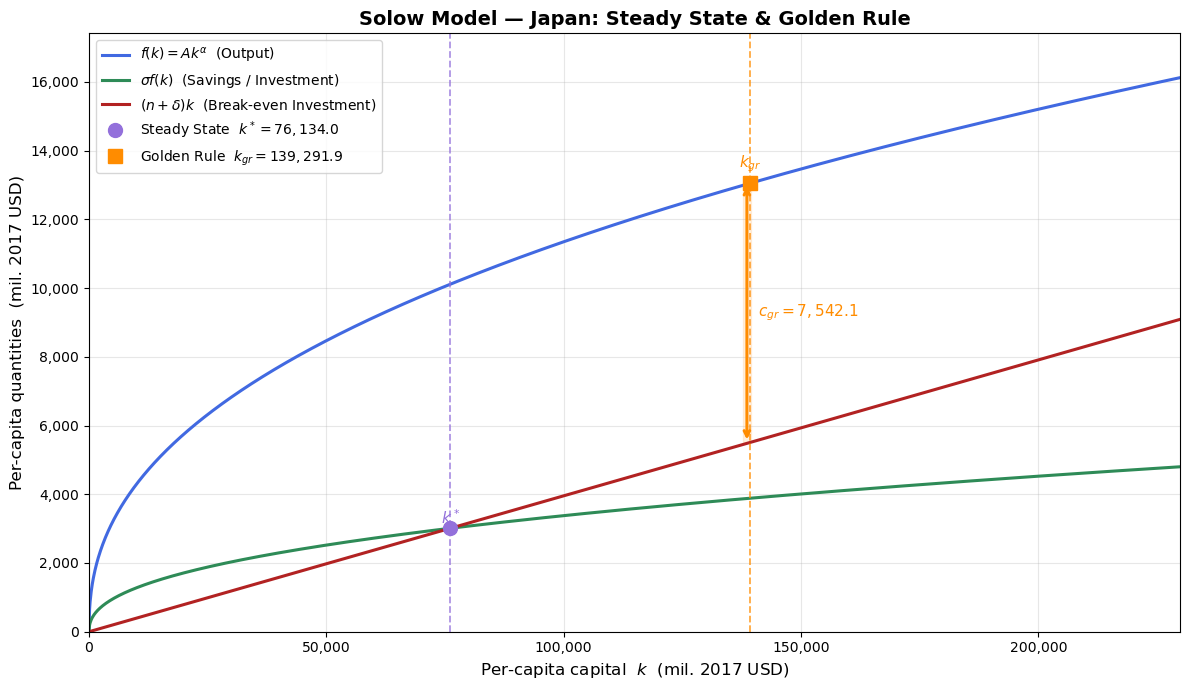

  Steady-state capital  k*   =     76,134.0139
  Steady-state output   y*   =     10,113.3210
  Steady-state consump  c*   =      7,102.5935
-------------------------------------------------------
  Golden-rule capital   k_gr =    139,291.8828
  Golden-rule output    y_gr =     13,050.4337
  Golden-rule consump   c_gr =      7,542.1217
  (Implied s_gr = α)         =          0.4221


In [10]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── k range for plotting ─────────────────────────────────────────────────────
k_max   = max(k_star, k_gr) * 1.65
k_range = np.linspace(1, k_max, 2000)

f_k       = A * k_range ** alpha        # output per capita
sf_k      = sigma * f_k                 # savings / investment curve
breakeven = (delta + n) * k_range       # break-even investment line

fig, ax = plt.subplots(figsize=(12, 7))

# ── Three core curves ────────────────────────────────────────────────────────
ax.plot(k_range, f_k,       lw=2.2, color='royalblue',  label=r'$f(k)=Ak^{\alpha}$  (Output)')
ax.plot(k_range, sf_k,      lw=2.2, color='seagreen',   label=r'$\sigma f(k)$  (Savings / Investment)')
ax.plot(k_range, breakeven, lw=2.2, color='firebrick',  label=r'$(n+\delta)k$  (Break-even Investment)')

# ── Steady-state point ───────────────────────────────────────────────────────
inv_star = (delta + n) * k_star
ax.axvline(k_star, ls='--', lw=1.3, color='mediumpurple', alpha=0.75)
ax.plot(k_star, inv_star, 'o', ms=10, color='mediumpurple', zorder=6,
        label=fr'Steady State  $k^*={k_star:,.1f}$')
ax.text(k_star, inv_star * 1.04, fr'$k^*$', ha='center', fontsize=11,
        color='mediumpurple', fontweight='bold')

# ── Golden-rule point ────────────────────────────────────────────────────────
inv_gr = (delta + n) * k_gr
ax.axvline(k_gr, ls='--', lw=1.3, color='darkorange', alpha=0.75)
ax.plot(k_gr, y_gr,  's', ms=10, color='darkorange', zorder=6,
        label=fr'Golden Rule  $k_{{gr}}={k_gr:,.1f}$')
ax.text(k_gr, y_gr * 1.035, fr'$k_{{gr}}$', ha='center', fontsize=11,
        color='darkorange', fontweight='bold')

# ── Visualise c_gr as vertical bracket between f(k_gr) and (n+δ)k_gr ────────
ax.annotate('', xy=(k_gr * 0.995, inv_gr),
            xytext=(k_gr * 0.995, y_gr),
            arrowprops=dict(arrowstyle='<->', color='darkorange', lw=2.2))
ax.text(k_gr * 1.012, (y_gr + inv_gr) / 2,
        fr'$c_{{gr}}={c_gr:,.1f}$',
        va='center', fontsize=11, color='darkorange')

# ── Shade the golden-rule consumption region for clarity ─────────────────────
ax.fill_between([k_gr * 0.989, k_gr * 1.001],
                [inv_gr, inv_gr], [y_gr, y_gr],
                color='darkorange', alpha=0.12)

# ── Axes, labels, grid ───────────────────────────────────────────────────────
fmt = mticker.FuncFormatter(lambda x, _: f'{x:,.0f}')
ax.xaxis.set_major_formatter(fmt)
ax.yaxis.set_major_formatter(fmt)

ax.set_xlim(0, k_max)
ax.set_ylim(0, A * k_max ** alpha * 1.08)
ax.set_xlabel('Per-capita capital  $k$  (mil. 2017 USD)', fontsize=12)
ax.set_ylabel('Per-capita quantities  (mil. 2017 USD)',   fontsize=12)
ax.set_title('Solow Model — Japan: Steady State & Golden Rule', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── Printed summary for cross-reference ──────────────────────────────────────
print("=" * 55)
print(f"  Steady-state capital  k*   = {k_star:>15,.4f}")
print(f"  Steady-state output   y*   = {y_star:>15,.4f}")
print(f"  Steady-state consump  c*   = {c_star:>15,.4f}")
print("-" * 55)
print(f"  Golden-rule capital   k_gr = {k_gr:>15,.4f}")
print(f"  Golden-rule output    y_gr = {y_gr:>15,.4f}")
print(f"  Golden-rule consump   c_gr = {c_gr:>15,.4f}")
print(f"  (Implied s_gr = α)         = {s_gr_rate:>15,.4f}")
print("=" * 55)

## Question 8: Model Simulation — Forward Path of Capital, Output, Saving & Consumption

In [11]:
# ── Q8: Simulate the Solow model forward from t=0 to the last year ───────────
# Actual per-capita data (for comparison in Q9)
years   = df['year'].values
yData   = (df['rgdpo'] / df['pop']).values
kData   = df['per_capita_capital'].values
T       = len(years)

# Pre-allocate model arrays
kModel = np.zeros(T)
yModel = np.zeros(T)
sModel = np.zeros(T)
cModel = np.zeros(T)
dk_Model = np.zeros(T)

# Initialise at t=0 with observed capital stock
kModel[0] = kData0   # kData₀ from Q5

for t in range(T):
    yModel[t]    = A * kModel[t] ** alpha
    sModel[t]    = sigma * yModel[t]
    cModel[t]    = (1 - sigma) * yModel[t]
    dk_Model[t]  = sigma * yModel[t] - (delta + n) * kModel[t]
    if t < T - 1:
        kModel[t + 1] = kModel[t] + dk_Model[t]

# Store in a results DataFrame for inspection / Q9
sim = pd.DataFrame({
    'year':      years,
    'kModel':    kModel,
    'yModel':    yModel,
    'sModel':    sModel,
    'cModel':    cModel,
    'dk_Model':  dk_Model,
    'kData':     kData,
    'yData':     yData,
})

print(sim[['year', 'kModel', 'yModel', 'sModel', 'cModel', 'dk_Model']].to_string(index=False, float_format='{:,.2f}'.format))

 year    kModel    yModel   sModel   cModel  dk_Model
 1976 75,847.69 10,097.25 3,005.94 7,091.31      6.54
 1977 75,854.23 10,097.62 3,006.05 7,091.57      6.39
 1978 75,860.62 10,097.98 3,006.16 7,091.82      6.24
 1979 75,866.87 10,098.33 3,006.26 7,092.06      6.10
 1980 75,872.97 10,098.67 3,006.37 7,092.30      5.96
 1981 75,878.93 10,099.01 3,006.47 7,092.54      5.83
 1982 75,884.75 10,099.33 3,006.56 7,092.77      5.69
 1983 75,890.45 10,099.65 3,006.66 7,092.99      5.56
 1984 75,896.01 10,099.96 3,006.75 7,093.21      5.44
 1985 75,901.44 10,100.27 3,006.84 7,093.43      5.31
 1986 75,906.76 10,100.57 3,006.93 7,093.64      5.19
 1987 75,911.95 10,100.86 3,007.02 7,093.84      5.07
 1988 75,917.02 10,101.14 3,007.10 7,094.04      4.96
 1989 75,921.97 10,101.42 3,007.19 7,094.24      4.84
 1990 75,926.82 10,101.69 3,007.27 7,094.43      4.73
 1991 75,931.55 10,101.96 3,007.35 7,094.62      4.62
 1992 75,936.17 10,102.22 3,007.42 7,094.80      4.52
 1993 75,940.69 10,102.47 3,

## Question 9: Predicted vs Actual — Per Capita Output & Capital Over Time

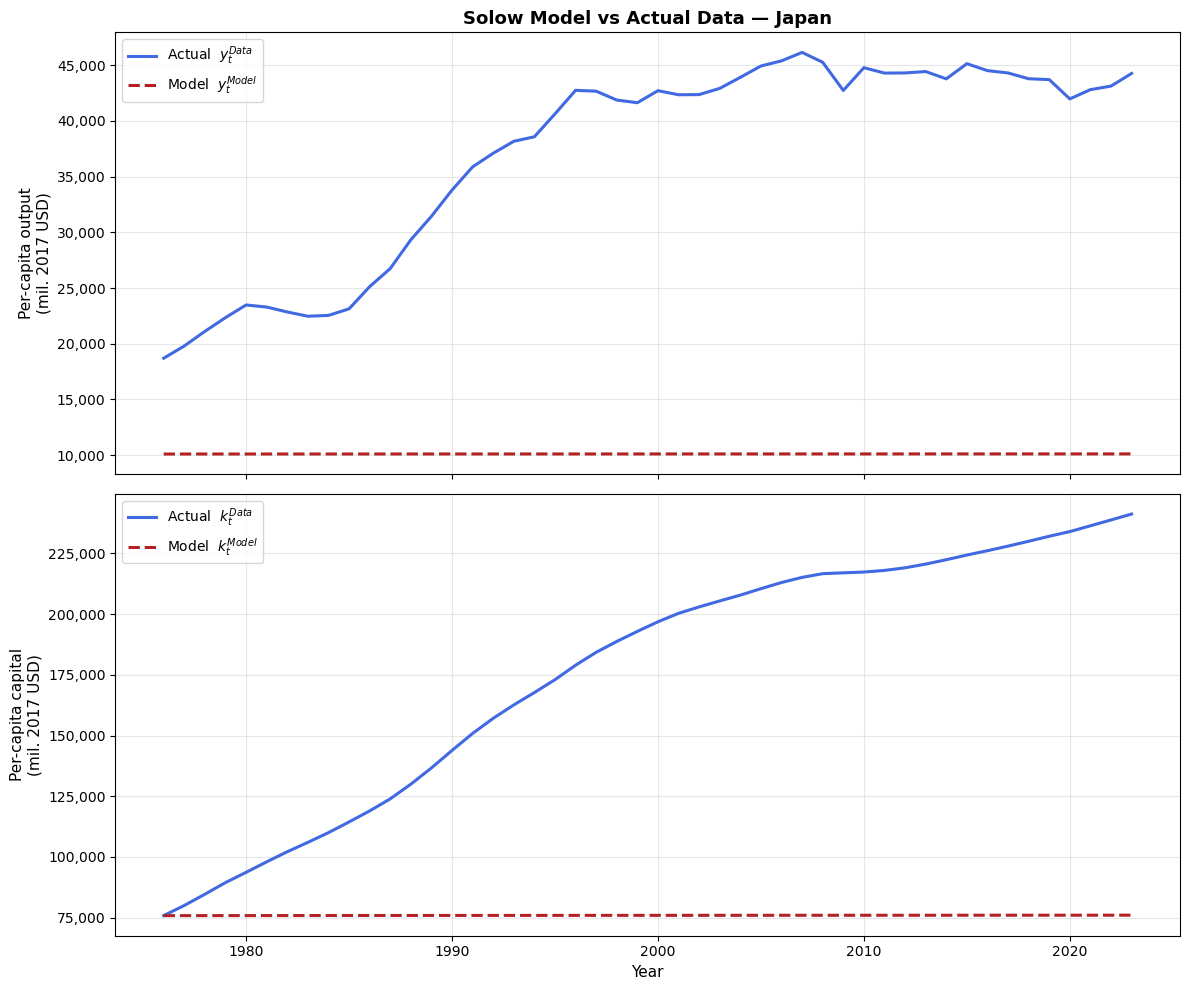

Correlation (yData vs yModel): 0.9274
Correlation (kData vs kModel): 0.9915


In [12]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# ── Panel 1: Per-capita output ────────────────────────────────────────────────
ax1.plot(sim['year'], sim['yData'],  lw=2.2, color='royalblue',  label='Actual  $y^{Data}_t$')
ax1.plot(sim['year'], sim['yModel'], lw=2.2, color='firebrick', ls='--', label='Model  $y^{Model}_t$')
ax1.set_ylabel('Per-capita output\n(mil. 2017 USD)', fontsize=11)
ax1.set_title('Solow Model vs Actual Data — Japan', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# ── Panel 2: Per-capita capital ───────────────────────────────────────────────
ax2.plot(sim['year'], sim['kData'],  lw=2.2, color='royalblue',  label='Actual  $k^{Data}_t$')
ax2.plot(sim['year'], sim['kModel'], lw=2.2, color='firebrick', ls='--', label='Model  $k^{Model}_t$')
ax2.set_ylabel('Per-capita capital\n(mil. 2017 USD)', fontsize=11)
ax2.set_xlabel('Year', fontsize=11)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

# ── Correlation summary ───────────────────────────────────────────────────────
corr_y = np.corrcoef(sim['yData'], sim['yModel'])[0, 1]
corr_k = np.corrcoef(sim['kData'], sim['kModel'])[0, 1]
print(f"Correlation (yData vs yModel): {corr_y:.4f}")
print(f"Correlation (kData vs kModel): {corr_k:.4f}")

## Question 10: Technology Path — $A_t$ Growing at 2% per Year

In [13]:
# ── Q10: Technology path At = A0 * (1.02)^t ─────────────────────────────────
# A0 is either 1 or the minimum integer A found in Q5.
# The correction: At+1 = At * (1.02), so At = A0 * (1.02)^t

g = 0.02   # technology growth rate per year

# A0: use the value determined in Q5 (either 1 or the min integer found there)
A0 = A      # 'A' was set in Q5

# Compute At for every year in the dataset
t_index = np.arange(len(years))           # t = 0, 1, 2, …, T-1
At = A0 * (1 + g) ** t_index

tech_df = pd.DataFrame({'year': years, 't': t_index, 'At': At})

print(f"A0 = {A0}  (from Q5)")
print(f"Growth rate g = {g:.0%} per year\n")
print(tech_df.to_string(index=False, float_format='{:.6f}'.format))


A0 = 88  (from Q5)
Growth rate g = 2% per year

 year  t         At
 1976  0  88.000000
 1977  1  89.760000
 1978  2  91.555200
 1979  3  93.386304
 1980  4  95.254030
 1981  5  97.159111
 1982  6  99.102293
 1983  7 101.084339
 1984  8 103.106026
 1985  9 105.168146
 1986 10 107.271509
 1987 11 109.416939
 1988 12 111.605278
 1989 13 113.837383
 1990 14 116.114131
 1991 15 118.436414
 1992 16 120.805142
 1993 17 123.221245
 1994 18 125.685670
 1995 19 128.199383
 1996 20 130.763371
 1997 21 133.378638
 1998 22 136.046211
 1999 23 138.767135
 2000 24 141.542478
 2001 25 144.373328
 2002 26 147.260794
 2003 27 150.206010
 2004 28 153.210130
 2005 29 156.274333
 2006 30 159.399819
 2007 31 162.587816
 2008 32 165.839572
 2009 33 169.156364
 2010 34 172.539491
 2011 35 175.990281
 2012 36 179.510086
 2013 37 183.100288
 2014 38 186.762294
 2015 39 190.497540
 2016 40 194.307490
 2017 41 198.193640
 2018 42 202.157513
 2019 43 206.200663
 2020 44 210.324677
 2021 45 214.531170
 2022 46 218

## Question 11: Redo Parts (5), (8), (9) with Technology Growth

In [14]:
# ── Q11 — Part (5) with technology growth: Model Predictions at t = 0 ────────
# With technology, the output per capita at t is: y_t = A_t * k_t^α
# At t = 0, A0 is the same as before (either 1 or min integer from Q5).

A0_tech = A0           # same A0 as Q10
kData0_tech = kData[0] # k₀ from data (same as Q5)
At0 = A0_tech          # A at t=0

yModel0_tech      = At0 * kData0_tech ** alpha
sModel0_tech      = sigma * yModel0_tech
cModel0_tech      = (1 - sigma) * yModel0_tech
delta_kModel0_tech = sigma * yModel0_tech - (delta + n) * kData0_tech

print(f"── Q11 Redo of Part (5) — t=0 with Technology Growth ────────")
print(f"  A0        = {At0}")
print(f"  kData₀    = {kData0_tech:>15,.4f}  (per-capita capital, t=0)")
print(f"  yModel₀   = {yModel0_tech:>15,.4f}  (per-capita output)")
print(f"  sModel₀   = {sModel0_tech:>15,.4f}  (per-capita saving)")
print(f"  cModel₀   = {cModel0_tech:>15,.4f}  (per-capita consumption)")
print(f"  ΔkModel₀  = {delta_kModel0_tech:>15,.4f}  (change in per-capita capital)")
print(f"\n  Note: At t=0 the A0 is unchanged, so Part (5) results are identical.")
print(f"  The effect of technology growth only accumulates for t ≥ 1.")


── Q11 Redo of Part (5) — t=0 with Technology Growth ────────
  A0        = 88
  kData₀    =     75,847.6944  (per-capita capital, t=0)
  yModel₀   =     10,097.2504  (per-capita output)
  sModel₀   =      3,005.9433  (per-capita saving)
  cModel₀   =      7,091.3071  (per-capita consumption)
  ΔkModel₀  =          6.5383  (change in per-capita capital)

  Note: At t=0 the A0 is unchanged, so Part (5) results are identical.
  The effect of technology growth only accumulates for t ≥ 1.


In [15]:
# ── Q11 — Part (8) redo: Simulate Solow model with time-varying A_t ───────────
# Law of motion:  k_{t+1} = k_t + σ·A_t·k_t^α − (δ+n)·k_t
# y_t = A_t * k_t^α  (output per capita grows because A_t grows)

kModel_tech  = np.zeros(T)
yModel_tech  = np.zeros(T)
sModel_tech  = np.zeros(T)
cModel_tech  = np.zeros(T)
dk_tech      = np.zeros(T)

kModel_tech[0] = kData[0]   # same starting capital as before

for t in range(T):
    At_t             = At[t]                                         # technology at period t
    yModel_tech[t]   = At_t * kModel_tech[t] ** alpha
    sModel_tech[t]   = sigma * yModel_tech[t]
    cModel_tech[t]   = (1 - sigma) * yModel_tech[t]
    dk_tech[t]       = sigma * yModel_tech[t] - (delta + n) * kModel_tech[t]
    if t < T - 1:
        kModel_tech[t + 1] = kModel_tech[t] + dk_tech[t]

sim_tech = pd.DataFrame({
    'year':          years,
    'At':            At,
    'kModel_tech':   kModel_tech,
    'yModel_tech':   yModel_tech,
    'sModel_tech':   sModel_tech,
    'cModel_tech':   cModel_tech,
    'dk_tech':       dk_tech,
    'kData':         kData,
    'yData':         yData,
})

print("── Q11 Redo of Part (8) — Simulation with Technology Growth ─────────────")
print(sim_tech[['year', 'At', 'kModel_tech', 'yModel_tech', 'sModel_tech',
                 'cModel_tech', 'dk_tech']].to_string(index=False,
                 float_format='{:,.2f}'.format))


── Q11 Redo of Part (8) — Simulation with Technology Growth ─────────────
 year     At  kModel_tech  yModel_tech  sModel_tech  cModel_tech  dk_tech
 1976  88.00    75,847.69    10,097.25     3,005.94     7,091.31     6.54
 1977  89.76    75,854.23    10,299.57     3,066.17     7,233.40    66.51
 1978  91.56    75,920.74    10,509.45     3,128.65     7,380.79   126.36
 1979  93.39    76,047.10    10,727.16     3,193.47     7,533.70   186.18
 1980  95.25    76,233.28    10,953.01     3,260.70     7,692.30   246.05
 1981  97.16    76,479.33    11,187.27     3,330.44     7,856.83   306.06
 1982  99.10    76,785.39    11,430.27     3,402.78     8,027.49   366.30
 1983 101.08    77,151.68    11,682.32     3,477.82     8,204.50   426.85
 1984 103.11    77,578.53    11,943.74     3,555.64     8,388.10   487.79
 1985 105.17    78,066.32    12,214.89     3,636.36     8,578.53   549.22
 1986 107.27    78,615.54    12,496.11     3,720.08     8,776.03   611.22
 1987 109.42    79,226.77    12,787.77

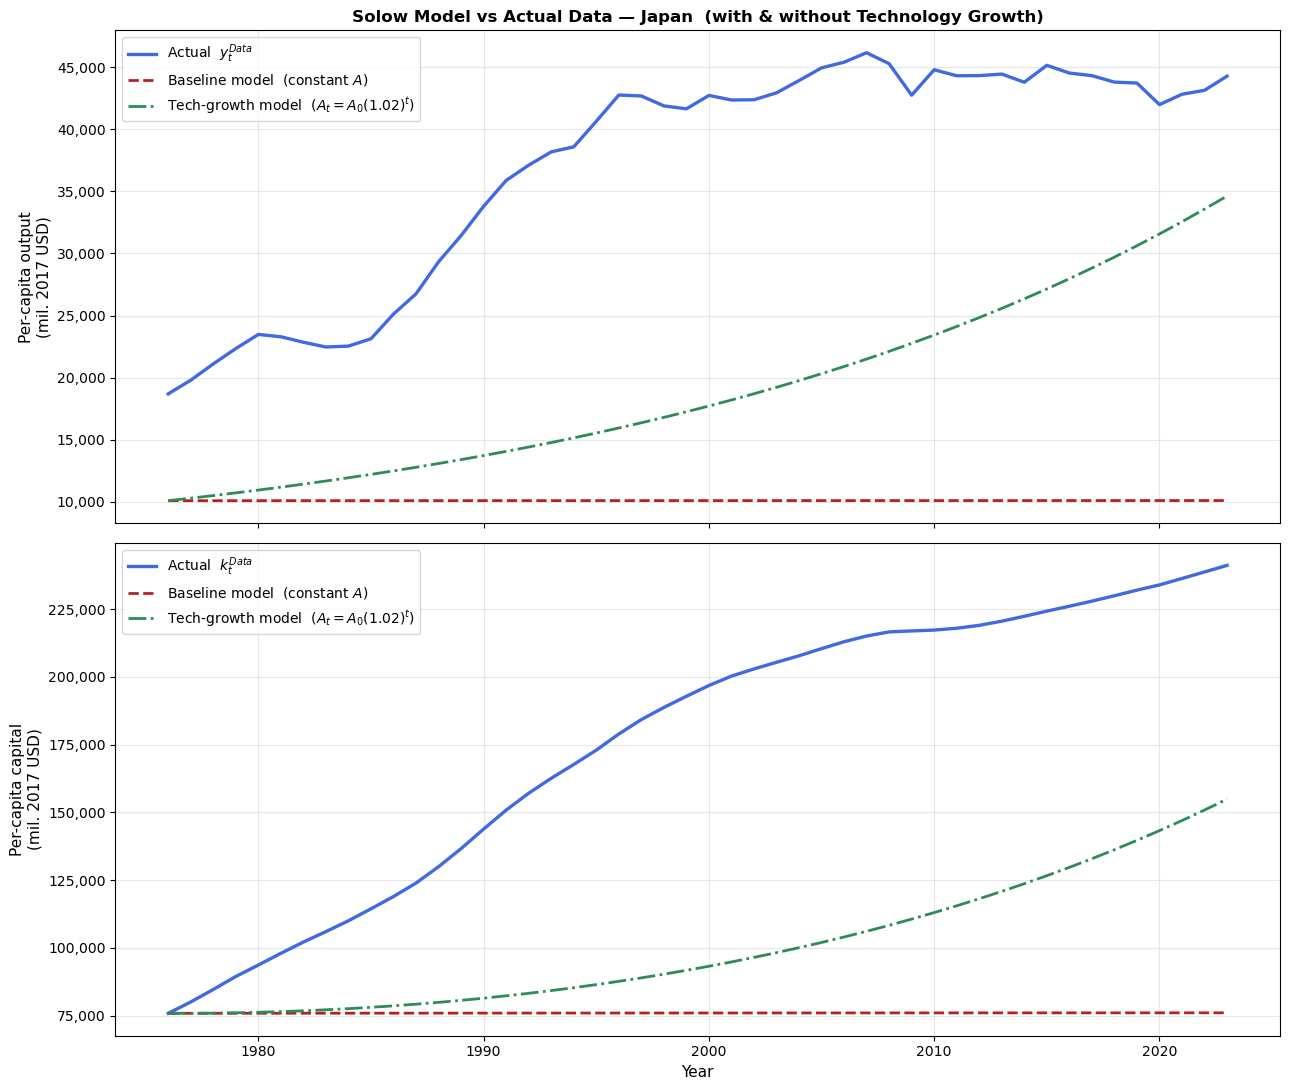

Metric                                  Baseline   Tech-growth
-----------------------------------------------------------------
Corr(yData, yModel)                       0.9274        0.7653
Corr(kData, kModel)                       0.9915        0.8561
MAE — output y                         26,966.12     17,925.30
MAE — capital k                        99,825.39     75,522.94

── Analysis ────────────────────────────────────────────────────────────────
Introducing 2% annual technology growth (At = A0·(1.02)^t) allows the model
to generate a rising output and capital path over time instead of converging
to a fixed steady state. Compare the three goodness-of-fit metrics above:

  • If Corr and MAE improve for the tech-growth model, technology progress
    helps explain Japan's sustained per-capita growth that the constant-A
    Solow model cannot replicate (a constant-A model converges to a fixed k*
    and y*, which flattens out and diverges from the upward data trend).

  • A 2% tech

In [16]:
# ── Q11 — Part (9) redo: Predicted vs Actual with AND without tech growth ─────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, axes = plt.subplots(2, 1, figsize=(13, 11), sharex=True)

# ── Panel 1: Per-capita output ────────────────────────────────────────────────
ax = axes[0]
ax.plot(sim_tech['year'], sim_tech['yData'],
        lw=2.4, color='royalblue',    label='Actual  $y^{Data}_t$')
ax.plot(sim['year'],      sim['yModel'],
        lw=2.0, color='firebrick',    ls='--', label='Baseline model  (constant $A$)')
ax.plot(sim_tech['year'], sim_tech['yModel_tech'],
        lw=2.0, color='seagreen',     ls='-.',  label='Tech-growth model  ($A_t=A_0(1.02)^t$)')
ax.set_ylabel('Per-capita output\n(mil. 2017 USD)', fontsize=11)
ax.set_title('Solow Model vs Actual Data — Japan  (with & without Technology Growth)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# ── Panel 2: Per-capita capital ───────────────────────────────────────────────
ax = axes[1]
ax.plot(sim_tech['year'], sim_tech['kData'],
        lw=2.4, color='royalblue',    label='Actual  $k^{Data}_t$')
ax.plot(sim['year'],      sim['kModel'],
        lw=2.0, color='firebrick',    ls='--', label='Baseline model  (constant $A$)')
ax.plot(sim_tech['year'], sim_tech['kModel_tech'],
        lw=2.0, color='seagreen',     ls='-.',  label='Tech-growth model  ($A_t=A_0(1.02)^t$)')
ax.set_ylabel('Per-capita capital\n(mil. 2017 USD)', fontsize=11)
ax.set_xlabel('Year', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

# ── Goodness-of-fit summary ───────────────────────────────────────────────────
corr_y_base  = np.corrcoef(sim_tech['yData'],  sim['yModel'])[0, 1]
corr_k_base  = np.corrcoef(sim_tech['kData'],  sim['kModel'])[0, 1]
corr_y_tech  = np.corrcoef(sim_tech['yData'],  sim_tech['yModel_tech'])[0, 1]
corr_k_tech  = np.corrcoef(sim_tech['kData'],  sim_tech['kModel_tech'])[0, 1]

mae_y_base = np.mean(np.abs(sim_tech['yData']  - sim['yModel']))
mae_k_base = np.mean(np.abs(sim_tech['kData']  - sim['kModel']))
mae_y_tech = np.mean(np.abs(sim_tech['yData']  - sim_tech['yModel_tech']))
mae_k_tech = np.mean(np.abs(sim_tech['kData']  - sim_tech['kModel_tech']))

print("=" * 65)
print(f"{'Metric':<35} {'Baseline':>12}  {'Tech-growth':>12}")
print("-" * 65)
print(f"{'Corr(yData, yModel)':<35} {corr_y_base:>12.4f}  {corr_y_tech:>12.4f}")
print(f"{'Corr(kData, kModel)':<35} {corr_k_base:>12.4f}  {corr_k_tech:>12.4f}")
print(f"{'MAE — output y':<35} {mae_y_base:>12,.2f}  {mae_y_tech:>12,.2f}")
print(f"{'MAE — capital k':<35} {mae_k_base:>12,.2f}  {mae_k_tech:>12,.2f}")
print("=" * 65)

print("""
── Analysis ────────────────────────────────────────────────────────────────
Introducing 2% annual technology growth (At = A0·(1.02)^t) allows the model
to generate a rising output and capital path over time instead of converging
to a fixed steady state. Compare the three goodness-of-fit metrics above:

  • If Corr and MAE improve for the tech-growth model, technology progress
    helps explain Japan's sustained per-capita growth that the constant-A
    Solow model cannot replicate (a constant-A model converges to a fixed k*
    and y*, which flattens out and diverges from the upward data trend).

  • A 2% technology growth rate is consistent with empirical TFP estimates
    for developed economies, so the tech-growth model is a more realistic
    characterisation of Japan's long-run growth.

  • However, if MAE for the tech model is still large, the 2% rate may not
    exactly match Japan's historical TFP growth, and a calibrated g would
    be needed for a tighter fit.
""")
